# 1. Аналіз даних: Прогноз ціни велосипеда
### Суть:
- У вас є датасет з даними про велосипеди:
    - рік випуску,
    - тип (міський, гірський),
    - матеріал рами,
    - вага,
    - бренд.
- Завдання:
    - Провести первинний аналіз:
        - розподіл ціни,
        - кількість брендів,
        - взаємозв’язки.
    - Побудувати парні графіки (scatterplots), boxplots для якісних змінних.
    - Виявити потенційні залежності.

Перші 5 записів наших даних:
   Рік_випуску       Тип Матеріал_рами  Вага_кг        Бренд  Ціна_грн
0         2016  Шосейний         Сталь     14.3        Scott   79899.0
1         2013   Дитячий      Алюміній      7.1         Trek   26524.0
2         2022   Міський      Алюміній      8.8        Giant   66789.0
3         2020  Гірський      Алюміній     13.0         Trek  198642.0
4         2017   Дитячий      Алюміній     14.6  Specialized   12986.0

-------------------------------------------------------------------------------------

--- Первинний аналіз ---
Загальна інформація про дані:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Рік_випуску    100 non-null    int32  
 1   Тип            100 non-null    object 
 2   Матеріал_рами  100 non-null    object 
 3   Вага_кг        100 non-null    float64
 4   Бренд          100 non-null   

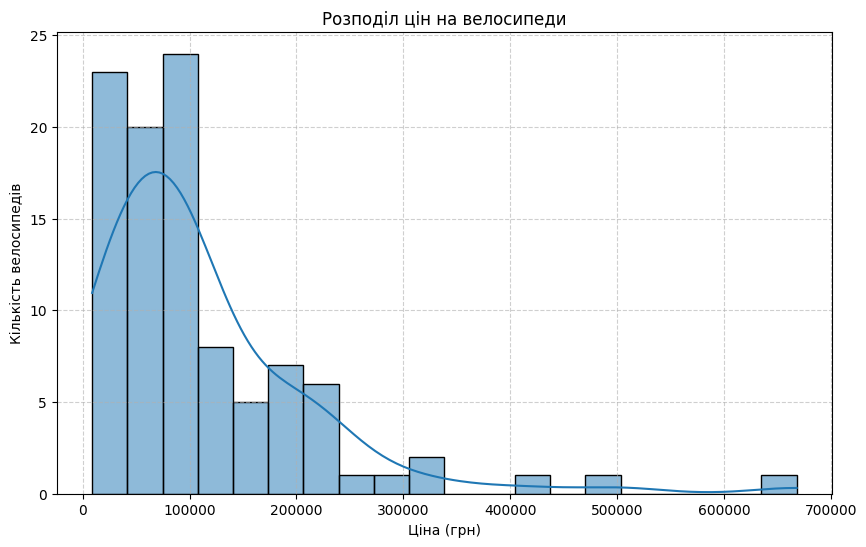


Кількість унікальних брендів: 6
Розподіл за брендами:
Бренд
Cube           22
Merida         20
Specialized    17
Giant          15
Scott          14
Trek           12
Name: count, dtype: int64

-------------------------------------------------------------------------------------

Розподіл за типом велосипеда:
Тип
Шосейний    32
Міський     30
Дитячий     24
Гірський    14
Name: count, dtype: int64

-------------------------------------------------------------------------------------

Розподіл за матеріалом рами:
Матеріал_рами
Алюміній    49
Сталь       27
Карбон      24
Name: count, dtype: int64

-------------------------------------------------------------------------------------

--- Візуалізація даних ---


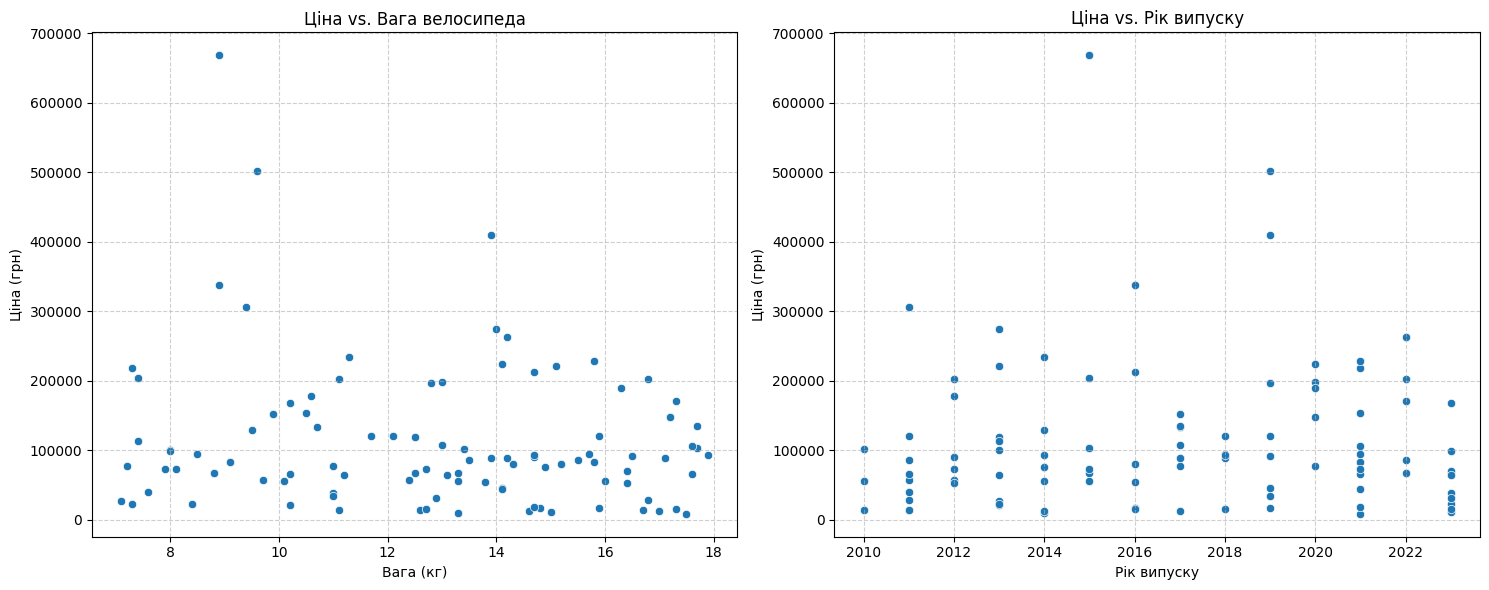


-------------------------------------------------------------------------------------



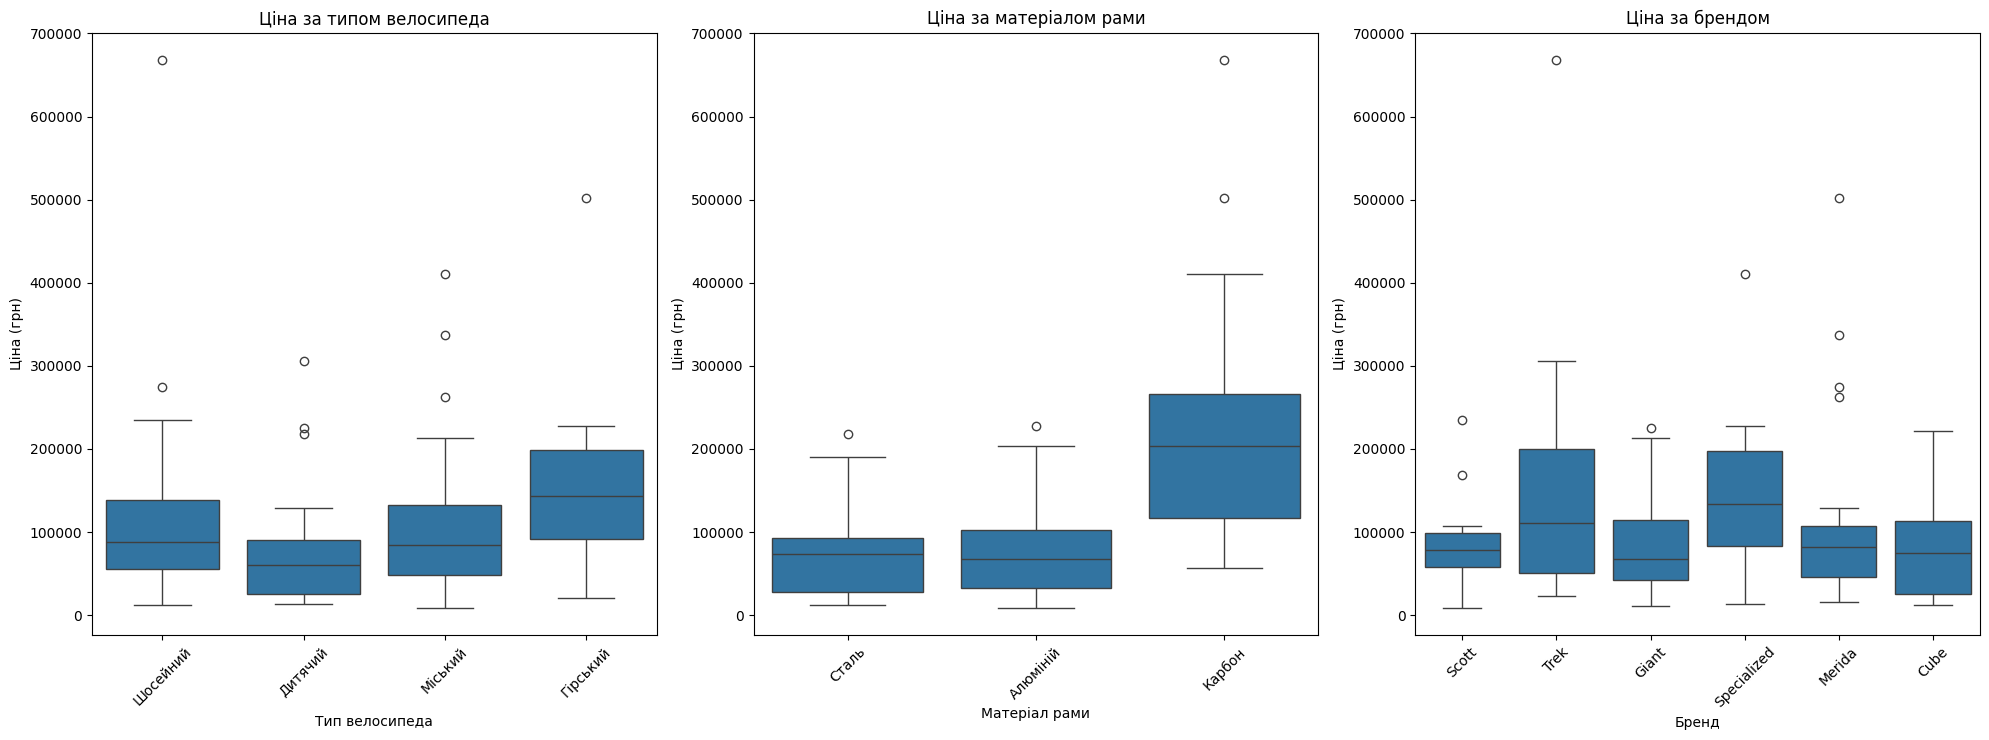

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42) # Магічне число

data_size = 100 # Наприклад 100 велосипедів

data = {
    'Рік_випуску': np.random.randint(2010, 2024, data_size),
    'Тип': np.random.choice(['Міський', 'Гірський', 'Шосейний', 'Дитячий'], data_size),
    'Матеріал_рами': np.random.choice(['Алюміній', 'Сталь', 'Карбон'], data_size, p=[0.5, 0.3, 0.2]),
    'Вага_кг': np.round(np.random.uniform(7, 18, data_size), 1),
    'Бренд': np.random.choice(['Giant', 'Merida', 'Trek', 'Specialized', 'Cube', 'Scott'], data_size),
    'Ціна_грн': np.round(np.random.uniform(5_000, 70_000, data_size), 0)
}

df = pd.DataFrame(data)

# Карбон дорожчий, новіші дорожчі, легші дорожчі, деякі бренди дорожчі
df.loc[df['Матеріал_рами'] == 'Карбон', 'Ціна_грн'] *= np.random.uniform(1.5, 3.0)
df.loc[df['Вага_кг'] < 10, 'Ціна_грн'] *= np.random.uniform(1.2, 2.0)
df.loc[df['Тип'] == 'Гірський', 'Ціна_грн'] *= np.random.uniform(1.0, 1.5)
df.loc[df['Тип'] == 'Шосейний', 'Ціна_грн'] *= np.random.uniform(1.2, 1.8)
df.loc[df['Бренд'].isin(['Specialized', 'Trek']), 'Ціна_грн'] *= np.random.uniform(1.2, 1.7)
df['Ціна_грн'] = df['Ціна_грн'] * (1 + (df['Рік_випуску'] - 2010) * 0.05) 
df['Ціна_грн'] = np.round(df['Ціна_грн'], 0)

print("Перші 5 записів наших даних:")
print(df.head())
print("\n-------------------------------------------------------------------------------------\n")


print("--- Первинний аналіз ---")
print("Загальна інформація про дані:")
print(df.info())
print("\n-------------------------------------------------------------------------------------\n")

print("Описова статистика для числових даних (Рік, Вага, Ціна):")
print(df.describe())
print("\n-------------------------------------------------------------------------------------\n")

# Графік
plt.figure(figsize=(10, 6))
sns.histplot(df['Ціна_грн'], kde=True, bins=20)
plt.title('Розподіл цін на велосипеди')
plt.xlabel('Ціна (грн)')
plt.ylabel('Кількість велосипедів')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"\nКількість унікальних брендів: {df['Бренд'].nunique()}")
print("Розподіл за брендами:")
print(df['Бренд'].value_counts())

print("\n-------------------------------------------------------------------------------------\n")
print("Розподіл за типом велосипеда:")
print(df['Тип'].value_counts())

print("\n-------------------------------------------------------------------------------------\n")
print("Розподіл за матеріалом рами:")
print(df['Матеріал_рами'].value_counts())
print("\n-------------------------------------------------------------------------------------\n")


print("--- Візуалізація даних ---")
# Парні графіки (scatterplots)
# Як Вага, Рік випуску впливають на Ціну
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(x='Вага_кг', y='Ціна_грн', data=df, ax=axes[0])
axes[0].set_title('Ціна vs. Вага велосипеда')
axes[0].set_xlabel('Вага (кг)')
axes[0].set_ylabel('Ціна (грн)')
axes[0].grid(True, linestyle='--', alpha=0.6)

sns.scatterplot(x='Рік_випуску', y='Ціна_грн', data=df, ax=axes[1])
axes[1].set_title('Ціна vs. Рік випуску')
axes[1].set_xlabel('Рік випуску')
axes[1].set_ylabel('Ціна (грн)')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()
print("\n-------------------------------------------------------------------------------------\n")

# Boxplots для якісних змінних 
# Як різні Типи, Матеріали, Бренди впливають на Ціну
fig, axes = plt.subplots(1, 3, figsize=(20, 7.5))

sns.boxplot(x='Тип', y='Ціна_грн', data=df, ax=axes[0])
axes[0].set_title('Ціна за типом велосипеда')
axes[0].set_xlabel('Тип велосипеда')
axes[0].set_ylabel('Ціна (грн)')
axes[0].ticklabel_format(style='plain', axis='y')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(x='Матеріал_рами', y='Ціна_грн', data=df, ax=axes[1])
axes[1].set_title('Ціна за матеріалом рами')
axes[1].set_xlabel('Матеріал рами')
axes[1].set_ylabel('Ціна (грн)')
axes[1].ticklabel_format(style='plain', axis='y')
axes[1].tick_params(axis='x', rotation=45)

sns.boxplot(x='Бренд', y='Ціна_грн', data=df, ax=axes[2])
axes[2].set_title('Ціна за брендом')
axes[2].set_xlabel('Бренд')
axes[2].set_ylabel('Ціна (грн)')
axes[2].ticklabel_format(style='plain', axis='y')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### Наші висновки:
- Ціна та Вага: На графіку "Ціна vs. Вага" ми можемо побачити, що зазвичай легші велосипеди дорожчі. Це логічно, адже легкі матеріали часто дорогі.
- Ціна та Рік випуску: На графіку "Ціна vs. Рік випуску" ми, ймовірно, побачимо, що новіші велосипеди, як правило, дорожчі, ніж старіші.
- Ціна та Тип велосипеда: На графіку-коробочці для типу, ми можемо помітити, що "Гірські" або "Шосейні" велосипеди, ймовірно, мають вищі ціни, ніж "Міські" або "Дитячі".
- Ціна та Матеріал рами: На графіку-коробочці для матеріалу рами, ми, швидше за все, побачимо, що велосипеди з карбоновою рамою коштують значно дорожче, ніж з алюмінієвою або сталевою.
- Ціна та Бренд: На графіку-коробочці для бренду, ми можемо побачити, що деякі бренди (наприклад, Specialized, Trek) мають вищі середні ціни, ніж інші. 

# 2. Factorize: Прогноз ціни оренди квартири
### Суть: 
- Є датасет з оголошеннями квартир:
    - район,
    - кількість кімнат,
    - площа,
    - наявність меблів (так/ні),
    - ціна.
- Завдання:
    - Закодувати ознаку «район» та «наявність меблів» за допомогою pd.factorize.
    - Побудувати модель регресії та оцінити її точність.

Перші 5 записів наших даних (нашої коробки):
           Район  Кількість_кімнат  Площа_квм Наявність_меблів  Ціна_грн
0        Оболонь                 3       73.0              Так   46500.0
1     Дарницький                 1       39.0              Так   16100.0
2  Голосіївський                 2       74.0               Ні   22300.0
3        Позняки                 2       73.0              Так   23700.0
4          Центр                 3       46.0              Так   62600.0

-------------------------------------------------------------------------------------

--- Кодування категоріальних ознак за допомогою pd.factorize ---
Райони закодовані: Index(['Оболонь', 'Дарницький', 'Голосіївський', 'Позняки', 'Центр'], dtype='object') -> [0 1 2 3 4]
Наявність меблів закодована: Index(['Так', 'Ні'], dtype='object') -> [0 1]

Дані після кодування (перші 5 записів):
           Район  Кількість_кімнат  Площа_квм Наявність_меблів  Ціна_грн  \
0        Оболонь                 3       73.0       

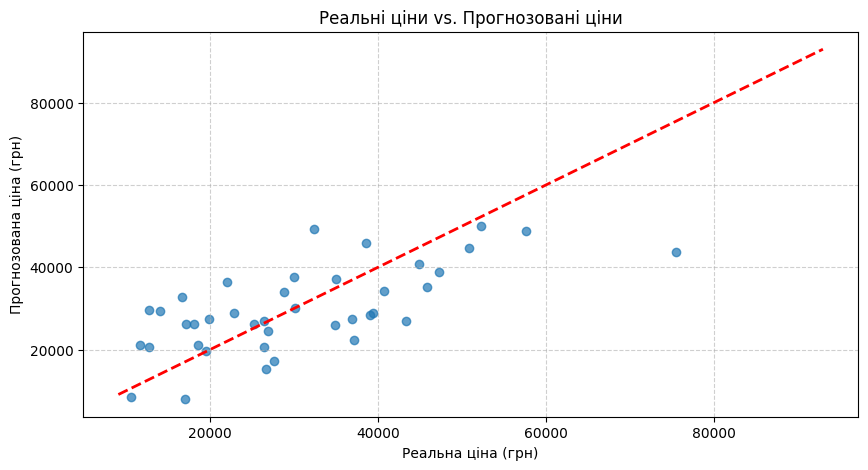

In [43]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42) # Магічне число

data_size = 200 # Наші 200 оголошень про квартири

data = {
    'Район': np.random.choice(['Центр', 'Оболонь', 'Позняки', 'Голосіївський', 'Дарницький'], data_size, p=[0.25, 0.2, 0.2, 0.2, 0.15]),
    'Кількість_кімнат': np.random.randint(1, 4, data_size), 
    'Площа_квм': np.round(np.random.uniform(30, 120, data_size), 0),
    'Наявність_меблів': np.random.choice(['Так', 'Ні'], data_size, p=[0.7, 0.3]),
    'Ціна_грн': np.round(np.random.uniform(5_000, 20_000, data_size), 0)
}

df = pd.DataFrame(data)

# Ціна залежить від району, кількості кімнат, площі, меблів / Райони з Києва
df.loc[df['Район'] == 'Центр', 'Ціна_грн'] *= np.random.uniform(1.3, 1.8)
df.loc[df['Район'] == 'Оболонь', 'Ціна_грн'] *= np.random.uniform(1.1, 1.4)
df.loc[df['Район'] == 'Позняки', 'Ціна_грн'] *= np.random.uniform(1.0, 1.2)
df.loc[df['Кількість_кімнат'] == 2, 'Ціна_грн'] *= np.random.uniform(1.2, 1.5)
df.loc[df['Кількість_кімнат'] == 3, 'Ціна_грн'] *= np.random.uniform(1.5, 2.0)
df['Ціна_грн'] *= (1 + df['Площа_квм'] / 100 * 0.5) 
df.loc[df['Наявність_меблів'] == 'Так', 'Ціна_грн'] *= np.random.uniform(1.1, 1.3)
df['Ціна_грн'] = np.round(df['Ціна_грн'] / 100) * 100 

print("Перші 5 записів наших даних (нашої коробки):")
print(df.head())
print("\n-------------------------------------------------------------------------------------\n")


print("--- Кодування категоріальних ознак за допомогою pd.factorize ---")
df['Район_encoded'], unique_districts = pd.factorize(df['Район'])
print(f"Райони закодовані: {unique_districts} -> {np.unique(df['Район_encoded'])}")

df['Наявність_меблів_encoded'], unique_furniture = pd.factorize(df['Наявність_меблів'])
print(f"Наявність меблів закодована: {unique_furniture} -> {np.unique(df['Наявність_меблів_encoded'])}")

print("\nДані після кодування (перші 5 записів):")
print(df.head())
print("\n-------------------------------------------------------------------------------------\n")


print("\n--- Побудова та оцінка моделі регресії ---")
# Вибираємо, які стовпчики будемо використовувати для передбачення ціни (наші "ознаки")
features = ['Район_encoded', 'Кількість_кімнат', 'Площа_квм', 'Наявність_меблів_encoded']
X = df[features] # Наша відома інформація
y = df['Ціна_грн'] # Будемо вгадати (ціна)

# Розділимо дані на "навчальні" та "тестові"
# test_size=0.2 - 20% даних ми залишимо для перевірки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Розмір навчальних даних: {len(X_train)} квартир")
print(f"Розмір тестових даних: {len(X_test)} квартир")

model = LinearRegression()  # Лінійна Регресія

print("\nНавчаємо модель...")
model.fit(X_train, y_train)
print("Модель навчена!")

# Прогнози для "тестових" даних
y_pred = model.predict(X_test)

# Наша оцінка
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) 
r2 = r2_score(y_test, y_pred)

print("\n--- Результати оцінки моделі ---")
print(f"MAE (Середня абсолютна помилка): {mae:.2f} грн") 
print(f"MSE (Середня квадратна помилка): {mse:.2f} грн²")
print(f"RMSE (Корінь із середньої квадратної помилки): {rmse:.2f} грн") 
print(f"R² (Коефіцієнт детермінації): {r2:.4f}") 
print("\n-------------------------------------------------------------------------------------\n")

# Візуалізація 
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Червона лінія - це якби модель вгадала ідеально
plt.title('Реальні ціни vs. Прогнозовані ціни')
plt.xlabel('Реальна ціна (грн)')
plt.ylabel('Прогнозована ціна (грн)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Наша оцінка точності:
- MAE (Середня абсолютна помилка): Чим менше , тим краще!
- RMSE (Корінь із середньої квадратної помилки): Чим менше, тим краще.
- R² (Коефіцієнт детермінації): Це "оцінка" нашої моделі, від 0 до 1. Чим більше, тим краще.

# 3. One-hot encoding: Вартість навчання у вузах
### Суть: 
- Датасет містить інформацію про університети:
    - країна,
    - тип (приватний/державний),
    - програма (бакалавр, магістр),
    - рік,
    - ціна.
- Завдання:
    - Застосувати one-hot кодування для тип та програма.
    - Побудувати модель лінійної регресії.
    - Проаналізувати вплив різних факторів на вартість навчання.

Перші 5 записів наших даних:
      Країна        Тип  Програма  Рік_вступу  Ціна_USD
0        США  Приватний  Бакалавр        2024  274300.0
1     Канада  Державний  Бакалавр        2022   13900.0
2  Німеччина  Державний  Бакалавр        2024   17000.0
3    Україна  Державний  Бакалавр        2022   12700.0
4        США  Державний  Бакалавр        2023   48600.0

-------------------------------------------------------------------------------------

--- Застосування One-Hot кодування ---

-------------------------------------------------------------------------------------

Дані після One-Hot кодування (перші 5 записів):
   Рік_вступу  Ціна_USD  Тип_Державний  Тип_Приватний  Програма_Бакалавр  \
0        2024  274300.0              0              1                  1   
1        2022   13900.0              1              0                  1   
2        2024   17000.0              1              0                  1   
3        2022   12700.0              1              0               

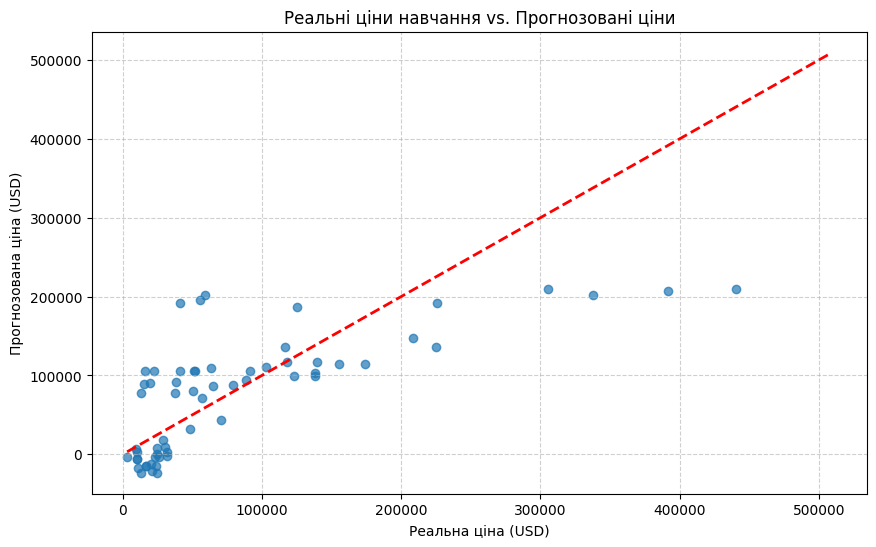

In [46]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42) # Магічне число

data_size = 300 # Наприклад 300 університетів

data = {
    'Країна': np.random.choice(['США', 'Україна', 'Німеччина', 'Польща', 'Канада'], data_size, p=[0.4, 0.2, 0.15, 0.15, 0.1]),
    'Тип': np.random.choice(['Приватний', 'Державний'], data_size, p=[0.4, 0.6]),
    'Програма': np.random.choice(['Бакалавр', 'Магістр'], data_size, p=[0.6, 0.4]),
    'Рік_вступу': np.random.randint(2020, 2025, data_size),
    'Ціна_USD': np.round(np.random.uniform(2_000, 25_000, data_size), 0)
}

df = pd.DataFrame(data)

# Ціна залежить від країни, типу, програми, року
df.loc[df['Тип'] == 'Приватний', 'Ціна_USD'] *= np.random.uniform(1.5, 3.0)
df.loc[df['Програма'] == 'Магістр', 'Ціна_USD'] *= np.random.uniform(1.2, 1.8)
df.loc[df['Країна'] == 'США', 'Ціна_USD'] *= np.random.uniform(2.5, 5.0)
df.loc[df['Країна'] == 'Канада', 'Ціна_USD'] *= np.random.uniform(1.8, 3.5)
df.loc[df['Країна'] == 'Німеччина', 'Ціна_USD'] *= np.random.uniform(0.8, 1.2)
df['Ціна_USD'] *= (1 + (df['Рік_вступу'] - 2018) * 0.05)
df['Ціна_USD'] = np.round(df['Ціна_USD'] / 100) * 100 

print("Перші 5 записів наших даних:")
print(df.head())
print("\n-------------------------------------------------------------------------------------\n")


print("--- Застосування One-Hot кодування ---")
df_encoded = pd.get_dummies(df, columns=['Тип', 'Програма'], drop_first=False, dtype=int)
df_encoded = pd.get_dummies(df_encoded, columns=['Країна'], drop_first=False, dtype=int)
print("\n-------------------------------------------------------------------------------------\n")


print("Дані після One-Hot кодування (перші 5 записів):")
print(df_encoded.head())
print("\n-------------------------------------------------------------------------------------\n")


print("--- Побудова та оцінка моделі лінійної регресії ---")
# Вибираємо, стовпчики
features = [col for col in df_encoded.columns if col not in ['Ціна_USD', 'Тип', 'Програма', 'Країна']]
X = df_encoded[features] # Наші дані
y = df_encoded['Ціна_USD'] # Щоб удемо вгадувати (ціна)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Розмір навчальних даних: {len(X_train)} університетів")
print(f"Розмір тестових даних: {len(X_test)} університетів")

model = LinearRegression() # Навчальна модель
print("\nНавчаємо модель...")
model.fit(X_train, y_train)
print("Модель навчена!")

# Наші прогнози на ціни на тестових даних
y_pred = model.predict(X_test)

# Наша точність моделі
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("\n-------------------------------------------------------------------------------------\n")


print("--- Результати оцінки моделі ---")
print(f"MAE (Середня абсолютна помилка): {mae:.2f} USD")
print(f"RMSE (Корінь із середньої квадратної помилки): {rmse:.2f} USD")
print(f"R² (Коефіцієнт детермінації): {r2:.4f}")
print("\n-------------------------------------------------------------------------------------\n")


# Графік
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.title('Реальні ціни навчання vs. Прогнозовані ціни')
plt.xlabel('Реальна ціна (USD)')
plt.ylabel('Прогнозована ціна (USD)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 4. MinMaxScaler: Прогноз витрат на ремонт будинку
- Суть:
    - Датасет із даними:
        - площа,
        - кількість поверхів,
        - стан (оцінка 1–10),
        - вік будинку,
        - вартість ремонту.
- Завдання:
    - Провести масштабування ознак за допомогою MinMaxScaler.
    - Побудувати модель регресії та інтерпретувати результати.

Наші будинки (перші 5 рядків):
    площа  кількість_поверхів  стан  вік_будинку  вартість_ремонту
0    152                   2     4           11             19686
1    229                   2     5           20             30706
2    142                   4     7           94             25265
3     64                   2     7           64             30218
4    156                   3     4            6             13846

-------------------------------------------------------------------------------------

Ми маємо 80 будинків для навчання та 20 будинків для перевірки.

-------------------------------------------------------------------------------------

Всі особливості будинків прирівняні до одного розміру (від 0 до 1).
Наші масштабовані особливості для навчання (перші 5 рядків):
       площа  кількість_поверхів      стан  вік_будинку
0  0.520161            0.666667  0.444444     0.393617
1  0.000000            0.666667  0.888889     0.893617
2  0.145161            0.000000  0.55

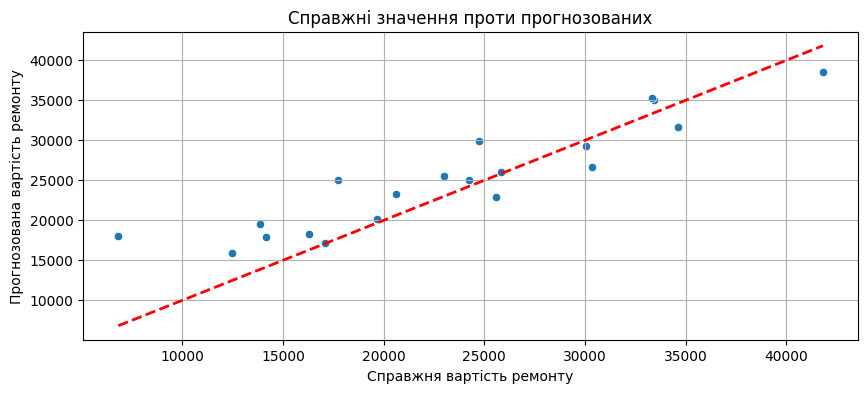

Ця картинка показує, як близько наші вгадки (сині крапки) знаходяться до справжньої вартості (червона лінія).
Чим ближче крапки до червоної лінії, тим краще вгадує наш помічник.

-------------------------------------------------------------------------------------



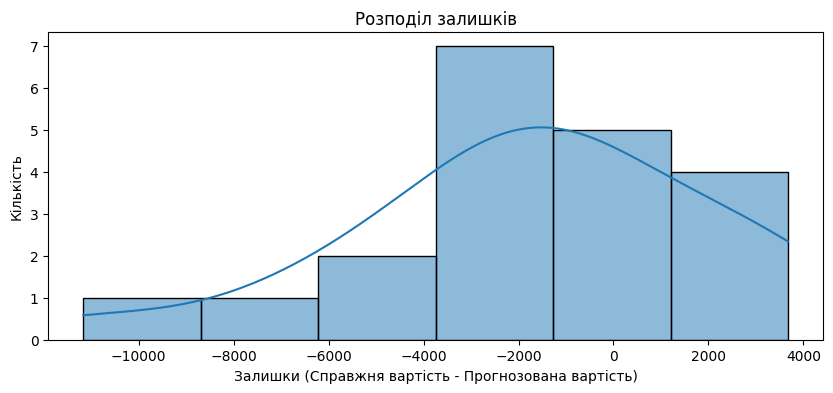

Ця картинка показує, наскільки часто наш помічник помиляється на певну суму.
Якщо горбик посередині і симетричний, це добре, бо помилки розподілені випадково.


In [49]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler # Додаємо MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42) # Магічне число
data = {
    'площа': np.random.randint(50, 300, 100),
    'кількість_поверхів': np.random.randint(1, 5, 100),
    'стан': np.random.randint(1, 11, 100),
    'вік_будинку': np.random.randint(5, 100, 100),
    'вартість_ремонту': np.random.randint(1_000, 50_000, 100)
}
df = pd.DataFrame(data)

# Наша формула вартості
df['вартість_ремонту'] = (df['площа'] * 50 +
                         df['кількість_поверхів'] * 500 +
                         (11 - df['стан']) * 1_000 + 
                         df['вік_будинку'] * 200 +
                         np.random.normal(0, 5_000, 100)).astype(int)


df['вартість_ремонту'] = df['вартість_ремонту'].apply(lambda x: max(1000, x))

print("Наші будинки (перші 5 рядків):\n", df.head())
print("\n-------------------------------------------------------------------------------------\n")


# X - особливості будинка (площа, поверхи, стан, вік)
# y - те, що ми хочемо вгадати (вартість ремонту)
X = df[['площа', 'кількість_поверхів', 'стан', 'вік_будинку']]
y = df['вартість_ремонту']

# Навчання та тест (80/20) помічника
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Ми маємо {len(X_train)} будинків для навчання та {len(X_test)} будинків для перевірки.")
print("\n-------------------------------------------------------------------------------------\n")


# Масштабування ознак за допомогою MinMaxScaler
print("Всі особливості будинків прирівняні до одного розміру (від 0 до 1).")
scaler = MinMaxScaler()

# Вчимо помічника 
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Наші масштабовані особливості для навчання (перші 5 рядків):\n", X_train_scaled_df.head())
print("\n-------------------------------------------------------------------------------------\n")


print("Наш помічник (модель Лінійної Регресії) починає вчитися на масштабованих даних.")
model = LinearRegression()
model.fit(X_train_scaled, y_train) # Навчаємо модель на масштабованих даних для навчання
print("Помічник навчився!")
print("\n-------------------------------------------------------------------------------------\n")


print("Тепер помічник вгадує вартість ремонту для будинків, які він ще не бачив.")
y_pred = model.predict(X_test_scaled)

# Провіряємо помічника
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Середня абсолютна помилка (MAE): {mae:,.2f} грн")
print(f"Середня квадратична помилка (MSE): {mse:,.2f}")
print(f"Коефіцієнт детермінації (R2): {r2:.2f}") #  (чим ближче до 1, тим краще)
if r2 > 0.7:
    print("Вау! Наш помічник досить добре розуміє, що впливає на вартість ремонту.")
elif r2 > 0.4:
    print("Непогано, але наш помічник може вчитися краще.")
else:
    print("Нашому помічнику ще потрібно багато вчитися.")
print("\n-------------------------------------------------------------------------------------\n")


print("\nНаскільки кожна особливість впливає на вартість ремонту (після масштабування):")
for feature, coef in zip(X.columns, model.coef_):
    print(f"- {feature}: {coef:,.2f}")
print("\n-------------------------------------------------------------------------------------\n")
# Інтерпретація коефіцієнтів:
# Якщо коефіцієнт позитивний, то збільшення цієї особливості (в її масштабованому діапазоні)
# призводить до збільшення вартості ремонту.
# Якщо коефіцієнт негативний, то збільшення особливості призводить до зменшення вартості.
# Величина коефіцієнта показує, наскільки сильно.


# Зробимо візуалізацію
plt.figure(figsize=(10, 4))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title('Справжні значення проти прогнозованих')
plt.xlabel('Справжня вартість ремонту')
plt.ylabel('Прогнозована вартість ремонту')
plt.grid(True)
plt.show()

print("Ця картинка показує, як близько наші вгадки (сині крапки) знаходяться до справжньої вартості (червона лінія).")
print("Чим ближче крапки до червоної лінії, тим краще вгадує наш помічник.")
print("\n-------------------------------------------------------------------------------------\n")

# Продовжимо
residuals = y_test - y_pred
plt.figure(figsize=(10, 4))
sns.histplot(residuals, kde=True)
plt.title('Розподіл залишків')
plt.xlabel('Залишки (Справжня вартість - Прогнозована вартість)')
plt.ylabel('Кількість')
plt.show()

print("Ця картинка показує, наскільки часто наш помічник помиляється на певну суму.")
print("Якщо горбик посередині і симетричний, це добре, бо помилки розподілені випадково.")

# 5. StandardScaler: Прогноз рейтингу книг
### Суть: 
- Датасет з інформацією про книги:
    - кількість сторінок,
    - жанр,
    - рік,
    - кількість відгуків,
    - середній рейтинг.
- Завдання:
    - Провести масштабування за допомогою StandardScaler.
    - Побудувати модель.
    - Порівняти результати з немасштабованими даними.

Наші книжки (перші 5 рядків):
    кількість_сторінок     жанр   рік  кількість_відгуків  середній_рейтинг
0                 202  Історія  1956                2928          4.842538
1                 535    Роман  2006                2219          4.451691
2                 960  Пригоди  1985                4191          4.956483
3                 370  Пригоди  1994                 718          4.065120
4                 206    Наука  1969                3607          4.555899

-------------------------------------------------------------------------------------

Ми маємо 160 книжок для навчання та 40 книжок для перевірки.

-------------------------------------------------------------------------------------

--- Навчаємо модель без масштабування ---
Результати для моделі без масштабування:
  MAE: 0.151
  MSE: 0.032
  R2: 0.724

-------------------------------------------------------------------------------------

--- Навчаємо модель зі StandardScaler ---
Результати для моделі зі Standa

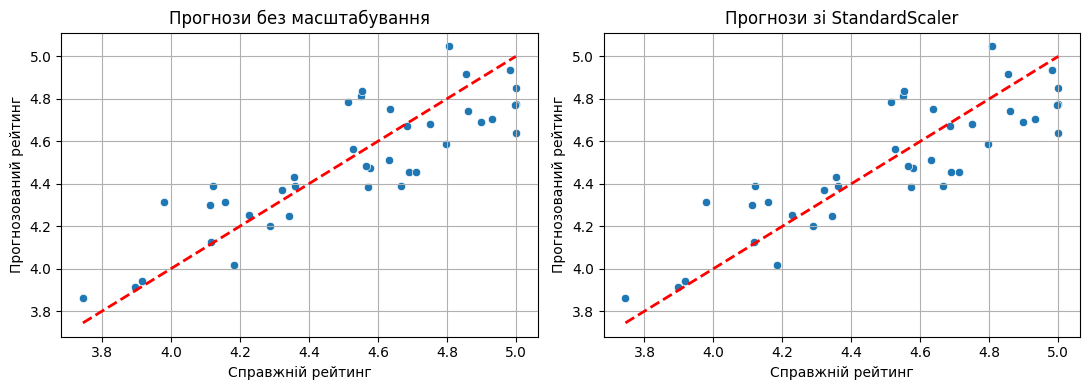

Показує, як прогнози моделей (сині крапки) порівнюються зі справжніми рейтингами (червона лінія).
Чим ближче крапки до червоної лінії, тим точніше вгадала модель.


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # !!! для нашої задачі
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


np.random.seed(42)
genres = ['Фантастика', 'Пригоди', 'Історія', 'Роман', 'Наука']
data = {
    'кількість_сторінок': np.random.randint(100, 1000, 200),
    'жанр': np.random.choice(genres, 200),
    'рік': np.random.randint(1950, 2024, 200),
    'кількість_відгуків': np.random.randint(5, 5000, 200),
    'середній_рейтинг': np.random.uniform(2.5, 5.0, 200)
}
df = pd.DataFrame(data)

#Для середнього рейтингу, створюємо формулу
df['середній_рейтинг'] = (df['кількість_сторінок'] * 0.001 +
                         df['кількість_відгуків'] * 0.0001 +
                         (2024 - df['рік']) * 0.005 + 
                         np.random.normal(0, 0.2, 200) + 3.5 
                         ).clip(2.5, 5.0) # наш рейтинг від 2.5 до 5.0

print("Наші книжки (перші 5 рядків):\n", df.head())
print("\n-------------------------------------------------------------------------------------\n")


X = df.drop('середній_рейтинг', axis=1) # ознаки
y = df['середній_рейтинг'] # ціль

# Розподіл на навчання та тест (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Ми маємо {len(X_train)} книжок для навчання та {len(X_test)} книжок для перевірки.")
print("\n-------------------------------------------------------------------------------------\n")


# Перетворимо текстовий жанр на числа (0 або 1)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['жанр'])
    ],
    remainder='passthrough'
)


      # МОДЕЛЬ 1: З НЕМАСШТАБОВАНИМИ ДАНИМИ
print("--- Навчаємо модель без масштабування ---")
# Спочатку обробляємо дані, потім навчаємо модель
model_unscaled = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('regressor', LinearRegression())])

model_unscaled.fit(X_train, y_train) # Навчаємо модель
y_pred_unscaled = model_unscaled.predict(X_test) # Робимо прогнози

# Оцінюємо результати
mae_unscaled = mean_absolute_error(y_test, y_pred_unscaled)
mse_unscaled = mean_squared_error(y_test, y_pred_unscaled)
r2_unscaled = r2_score(y_test, y_pred_unscaled)

print(f"Результати для моделі без масштабування:")
print(f"  MAE: {mae_unscaled:.3f}")
print(f"  MSE: {mse_unscaled:.3f}")
print(f"  R2: {r2_unscaled:.3f}")
print("\n-------------------------------------------------------------------------------------\n")


       # МОДЕЛЬ 2: З МАСШТАБОВАНИМИ ДАНИМИ (StandardScaler)
print("--- Навчаємо модель зі StandardScaler ---")
numeric_features = ['кількість_сторінок', 'рік', 'кількість_відгуків']

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features), # Масштабуємо числові
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['жанр']) # Кодуємо категоріальні
    ])

# Спочатку масштабуємо та обробляємо, потім навчаємо модель
model_scaled = Pipeline(steps=[('preprocessor', preprocessor_scaled),
                                ('regressor', LinearRegression())])

model_scaled.fit(X_train, y_train)  # Навчаємо модель
y_pred_scaled = model_scaled.predict(X_test)  # Робимо прогнози

# Оцінюємо результати
mae_scaled = mean_absolute_error(y_test, y_pred_scaled)
mse_scaled = mean_squared_error(y_test, y_pred_scaled)
r2_scaled = r2_score(y_test, y_pred_scaled)

print(f"Результати для моделі зі StandardScaler:")
print(f"  MAE: {mae_scaled:.3f}")
print(f"  MSE: {mse_scaled:.3f}")
print(f"  R2: {r2_scaled:.3f}")
print("\n-------------------------------------------------------------------------------------\n")


print("--- Порівняння результатів ---")
print(f"MAE (без масштабування): {mae_unscaled:.5f} | MAE (зі StandardScaler): {mae_scaled:.5f}")
print(f"MSE (без масштабування): {mse_unscaled:.5f} | MSE (зі StandardScaler): {mse_scaled:.5f}")
print(f"R2 (без масштабування): {r2_unscaled:.5f} | R2 (зі StandardScaler): {r2_scaled:.5f}")

if r2_scaled > r2_unscaled:
    print("\nВисновок: Модель зі StandardScaler показала кращі результати (вищий R2 та нижчі MAE/MSE).")
    print("Це означає, що масштабування допомогло нашому помічнику краще вгадувати рейтинги книг!")
elif r2_scaled < r2_unscaled:
    print("\nВисновок: Модель без масштабування показала трохи кращі результати.")
    print("Це не завжди так, але іноді для простих лінійних моделей різниця не велика або навіть відсутня.")
else:
    print("\nВисновок: Результати моделей з масштабуванням і без майже однакові.")
    print("Для лінійної регресії масштабування часто не впливає на R2, але може покращити швидкість навчання та стабільність для інших моделей.")
print("\n-------------------------------------------------------------------------------------\n")


# Покажемо все на малюнку
best_model_r2 = max(r2_unscaled, r2_scaled)

plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1) # Перший графік
sns.scatterplot(x=y_test, y=y_pred_unscaled)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title('Прогнози без масштабування')
plt.xlabel('Справжній рейтинг')
plt.ylabel('Прогнозований рейтинг')
plt.grid(True)

plt.subplot(1, 2, 2) # Другий графік
sns.scatterplot(x=y_test, y=y_pred_scaled)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title('Прогнози зі StandardScaler')
plt.xlabel('Справжній рейтинг')
plt.ylabel('Прогнозований рейтинг')
plt.grid(True)

plt.tight_layout()
plt.show()

print("Показує, як прогнози моделей (сині крапки) порівнюються зі справжніми рейтингами (червона лінія).")
print("Чим ближче крапки до червоної лінії, тим точніше вгадала модель.")

# 6. SimpleImputer: Прогноз ціни парфумів
- Суть:
    - Датасет із характеристиками парфумів:
        - бренд,
        - об’єм,
        - концентрація (EDT, EDP),
        - стать,
        - ціна.
        - Деякі значення об’єму та концентрації відсутні.
- Завдання:
    - Заповнити пропуски за допомогою SimpleImputer (стратегія: median для чисел, most_frequent для категорій).
    - Побудувати модель регресії та перевірити її стабільність.

Наші парфуми (перші 5 рядків, з можливими пропусками):
      бренд   обєм концентрація    стать        ціна
0  Versace    NaN          EDT  Унісекс  250.260010
1   Armani   50.0       Parfum  Жіночий  301.231372
2    Gucci  100.0       Parfum  Жіночий  366.134677
3   Armani  100.0          EDP  Жіночий  331.989342
4   Armani   30.0       Parfum  Жіночий  264.618879

-------------------------------------------------------------------------------------


Кількість пропусків у кожній колонці:
 бренд            0
обєм            25
концентрація     0
стать            0
ціна             0
dtype: int64

-------------------------------------------------------------------------------------

Конвеєр для обробки даних та навчання моделі створено.

-------------------------------------------------------------------------------------

Перевіряємо стабільність моделі, запускаючи її кілька разів з різними розділеннями даних.

--- Результати перевірки стабільності ---
Кількість запусків: 5
Середній R

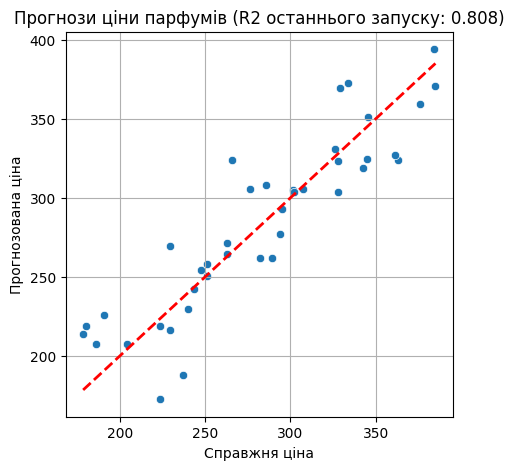

Цей графік показує, як наші вгадування ціни парфумів (сині крапки) відносяться до справжніх цін (червона лінія).
Чим ближче крапки до червоної лінії, тим точніше прогнозує модель.


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer # Для заповнення пропусків
from sklearn.ensemble import RandomForestRegressor # Для моделі регресії
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
brands = ['Dior', 'Chanel', 'Gucci', 'Versace', 'Armani']
concentrations = ['EDT', 'EDP', 'Parfum']
genders = ['Чоловічий', 'Жіночий', 'Унісекс']

data = {
    'бренд': np.random.choice(brands, 200),
    'обєм': np.random.choice([30, 50, 75, 100, np.nan], 200, p=[0.2, 0.3, 0.2, 0.2, 0.1]), # 10% пропусків
    'концентрація': np.random.choice(concentrations + [np.nan], 200, p=[0.3, 0.4, 0.2, 0.1]), # 10% пропусків
    'стать': np.random.choice(genders, 200),
    'ціна': np.random.uniform(50, 300, 200)
}
df = pd.DataFrame(data)

def get_concentration_price_effect(conc):
    if conc == 'EDP': return 50
    if conc == 'EDT': return 30
    if conc == 'Parfum': return 100
    return 0 # Для NaN або інших випадків

# Наша формула для вираховування ціни
df['ціна'] = (df['обєм'].fillna(df['обєм'].median()) * 2 + 
              df['концентрація'].apply(get_concentration_price_effect) +
              df['стать'].apply(lambda x: 20 if x == 'Унісекс' else 0) +
              np.random.normal(0, 20, 200) + 100
             ).clip(50, 400)

print("Наші парфуми (перші 5 рядків, з можливими пропусками):\n", df.head())
print("\n-------------------------------------------------------------------------------------\n")


print("\nКількість пропусків у кожній колонці:\n", df.isnull().sum())
print("\n-------------------------------------------------------------------------------------\n")

X = df.drop('ціна', axis=1)  # Ознаки
y = df['ціна']  # Змінна

numeric_features = ['обєм']
categorical_features = ['бренд', 'концентрація', 'стать']

# Для заповнення пропусків та масштабування
preprocessor = ColumnTransformer(
    transformers=[
        ('num_pipeline', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')), # Спочатку заповнюємо пропуски
            ('scaler', StandardScaler())                    # Потім масштабуємо
        ]), numeric_features),
        ('cat_pipeline', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')), # Спочатку заповнюємо пропуски
            ('onehot', OneHotEncoder(handle_unknown='ignore'))     # Потім кодуємо
        ]), categorical_features)
    ])


# Будуємо конвеєр (Pipeline) для обробки даних та моделювання
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42)) # Модель регресії
])

print("Конвеєр для обробки даних та навчання моделі створено.")
print("\n-------------------------------------------------------------------------------------\n")


print("Перевіряємо стабільність моделі, запускаючи її кілька разів з різними розділеннями даних.")
n_runs = 5 # Кількість разів, для повторювання навчання/тестування
r2_scores = []
mae_scores = []
mse_scores = []

for i in range(n_runs):
    X_train_run, X_test_run, y_train_run, y_test_run = train_test_split(X, y, test_size=0.2, random_state=i)

    full_pipeline.fit(X_train_run, y_train_run)  # Навчаємо модель   
    y_pred_run = full_pipeline.predict(X_test_run)  # Робимо прогнози

    # Наші показники
    r2_scores.append(r2_score(y_test_run, y_pred_run))
    mae_scores.append(mean_absolute_error(y_test_run, y_pred_run))
    mse_scores.append(mean_squared_error(y_test_run, y_pred_run))

print("\n--- Результати перевірки стабільності ---")
print(f"Кількість запусків: {n_runs}")
print(f"Середній R2: {np.mean(r2_scores):.3f} (Стандартне відхилення: {np.std(r2_scores):.3f})")
print(f"Середній MAE: {np.mean(mae_scores):.3f} (Стандартне відхилення: {np.std(mae_scores):.3f})")
print(f"Середній MSE: {np.mean(mse_scores):.3f} (Стандартне відхилення: {np.std(mse_scores):.3f})")

# Інтерпретація стабільності:
if np.std(r2_scores) < 0.05: 
    print("\nВисновок: Модель показує високу стабільність. Її точність не сильно коливається при зміні даних для навчання.")
else:
    print("\nВисновок: Модель має деякі коливання в точності, що може вказувати на меншу стабільність.")
    print("Можливо, варто спробувати інші моделі або додатково попрацювати з даними.")
print("\n-------------------------------------------------------------------------------------\n")


# Візуалізація прогнозів для останнього запуску
plt.figure(figsize=(5, 5))
sns.scatterplot(x=y_test_run, y=y_pred_run)
plt.plot([y_test_run.min(), y_test_run.max()], [y_test_run.min(), y_test_run.max()], '--r', linewidth=2)
plt.title(f'Прогнози ціни парфумів (R2 останнього запуску: {r2_scores[-1]:.3f})')
plt.xlabel('Справжня ціна')
plt.ylabel('Прогнозована ціна')
plt.grid(True)
plt.show()

print("Цей графік показує, як наші вгадування ціни парфумів (сині крапки) відносяться до справжніх цін (червона лінія).")
print("Чим ближче крапки до червоної лінії, тим точніше прогнозує модель.")

# 7. Формування ознак: Ціна мобільного телефону
- Суть:
    - Дані про телефони:
        - розмір екрану,
        - кількість ядер,
        - пам’ять,
        - наявність 5G,
        - рік.
- Завдання:
    - Створити нові ознаки:
        - “продуктивність” = ядра × частота (зафіксована),
        - “вік пристрою” = 2025 - рік.
    - Додати ці ознаки до датасету.
    - Побудувати модель і перевірити, чи нові ознаки покращують результат.

Ось як виглядають наші іграшкові телефони (перші 5 рядків):
    розмір_екрану  кількість_ядер  память наявність_5G   рік         ціна
0       6.061810               8     512           Ні  2019  1460.100401
1       6.926071               4     512          Так  2023  1814.832860
2       6.597991               6     128          Так  2022  1199.889068
3       6.397988               6     128           Ні  2020   955.938423
4       5.734028               8     512          Так  2019  1566.397506

-------------------------------------------------------------------------------------

Створюємо нові ознаки: 'продуктивність' та 'вік_пристрою'.
Ось як виглядають телефони з новими ознаками (перші 5 рядків):
    розмір_екрану  кількість_ядер  память наявність_5G   рік         ціна  \
0       6.061810               8     512           Ні  2019  1460.100401   
1       6.926071               4     512          Так  2023  1814.832860   
2       6.597991               6     128          Так  2022  1

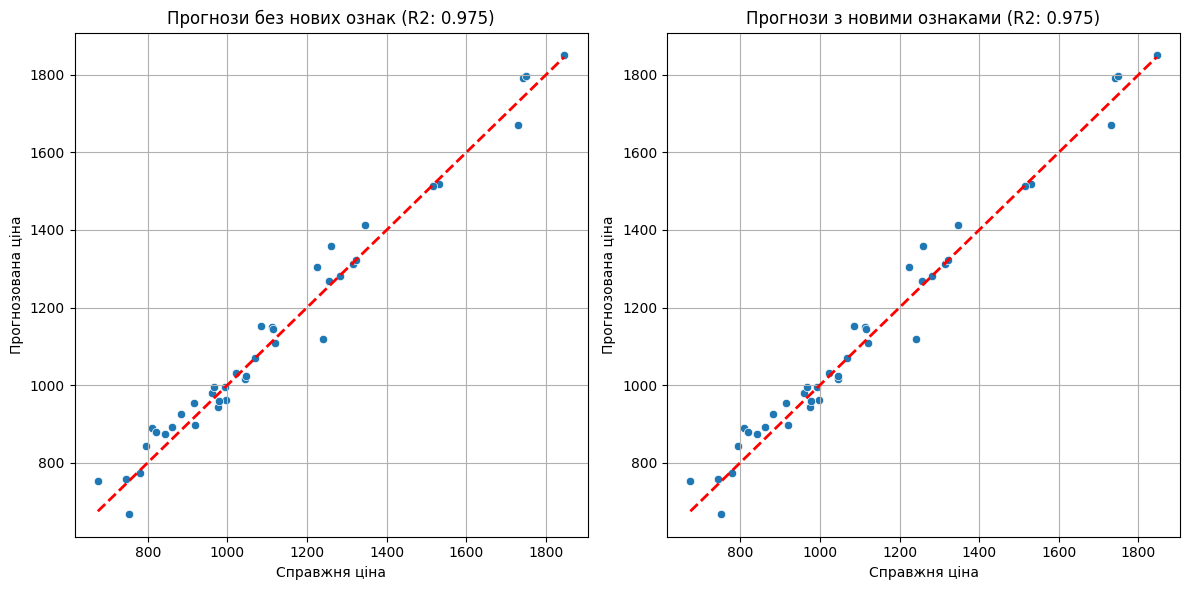

Графік показує, як близько наші вгадування ціни (сині крапки) знаходяться до справжньої ціни (червона лінія).


In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer


np.random.seed(42)
data = {
    'розмір_екрану': np.random.uniform(5.5, 7.0, 200),
    'кількість_ядер': np.random.choice([4, 6, 8], 200),
    'память': np.random.choice([64, 128, 256, 512], 200),
    'наявність_5G': np.random.choice(['Так', 'Ні'], 200, p=[0.7, 0.3]),
    'рік': np.random.randint(2019, 2024, 200),
    'ціна': np.random.uniform(200, 1500, 200)
}
df = pd.DataFrame(data)

# Наша формула
df['ціна'] = (df['розмір_екрану'] * 50 +
              df['кількість_ядер'] * 30 +
              df['память'] * 1.5 +
              df['наявність_5G'].apply(lambda x: 100 if x == 'Так' else 0) +
              (df['рік'] - 2018) * 80 + 
              np.random.normal(0, 50, 200) + 50 
             ).clip(150, 2000) # Ціна від і до

print("Ось як виглядають наші іграшкові телефони (перші 5 рядків):\n", df.head())
print("\n-------------------------------------------------------------------------------------\n")


print("Створюємо нові ознаки: 'продуктивність' та 'вік_пристрою'.")
fixed_frequency = 2.5 # GHz
df['продуктивність'] = df['кількість_ядер'] * fixed_frequency

current_year_for_age = 2025 
df['вік_пристрою'] = current_year_for_age - df['рік']

print("Ось як виглядають телефони з новими ознаками (перші 5 рядків):\n", df.head())
print("\n-------------------------------------------------------------------------------------\n")


X_original = df[['розмір_екрану', 'кількість_ядер', 'память', 'наявність_5G', 'рік']]  # для моделі без нових ознак
X_enhanced = df[['розмір_екрану', 'кількість_ядер', 'память', 'наявність_5G', 'рік',
                 'продуктивність', 'вік_пристрою']]   # для моделі з новими ознаками
y = df['ціна']


# Визначаємо числові та категоріальні колонки для препроцесингу
# Для X_original
numeric_features_original = ['розмір_екрану', 'кількість_ядер', 'память', 'рік']
categorical_features_original = ['наявність_5G']

# Для X_enhanced (додаємо нові числові ознаки)
numeric_features_enhanced = ['розмір_екрану', 'кількість_ядер', 'память', 'рік', 'продуктивність', 'вік_пристрою']
categorical_features_enhanced = ['наявність_5G']

# Для створення та оцінки моделі 
def train_and_evaluate_model(X_data, y_data, numeric_feats, categorical_feats, model_name):
    print(f"--- Навчаємо модель: {model_name} ---")

    # Розділяємо дані на навчання та тест
    X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

    # Створюємо препроцесор
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_feats), # Масштабуємо числові
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_feats) # Кодуємо категоріальні
        ])

    # Створюємо конвеєр
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression()) # Використовуємо LinearRegression, як просив у попередніх завданнях
    ])

    
    model_pipeline.fit(X_train, y_train)     # Навчаємо модель  
    y_pred = model_pipeline.predict(X_test)  # Робимо прогнози

    # Оцінюємо результати
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Результати для {model_name}:")
    print(f"  MAE: {mae:.3f}")
    print(f"  MSE: {mse:.3f}")
    print(f"  R2: {r2:.3f}")
    print("\n------------------------------------------------\n")
    return mae, mse, r2, y_pred, y_test


# Модель 1: Без нових ознак
mae_orig, mse_orig, r2_orig, y_pred_orig, y_test_orig = train_and_evaluate_model(
    X_original, y, numeric_features_original, categorical_features_original, "Модель без нових ознак"
)

# Модель 2: З новими ознаками
mae_enh, mse_enh, r2_enh, y_pred_enh, y_test_enh = train_and_evaluate_model(
    X_enhanced, y, numeric_features_enhanced, categorical_features_enhanced, "Модель з новими ознаками"
)

# Порівнюємо результати
print("--- Порівняння результатів ---")
print(f"R2 (без нових ознак): {r2_orig:.3f} | R2 (з новими ознаками): {r2_enh:.3f}")
print(f"MAE (без нових ознак): {mae_orig:.3f} | MAE (з новими ознаками): {mae_enh:.3f}")
print(f"MSE (без нових ознак): {mse_orig:.3f} | MSE (з новими ознаками): {mse_enh:.3f}")

if r2_enh > r2_orig:
    print("\nВисновок: Нові ознаки покращили результат! Модель з 'продуктивністю' та 'віком_пристрою' передбачає ціну телефону краще.")
elif r2_enh < r2_orig:
    print("\nВисновок: Нові ознаки не покращили результат, можливо, навіть трохи погіршили.")
    print("Це може статися, якщо нові ознаки не дуже інформативні або є дуже схожими на вже існуючі.")
else:
    print("\nВисновок: Нові ознаки не змінили результат суттєво.")
    print("Іноді потрібно експериментувати з різними новими ознаками, щоб знайти найкращі.")
print("\n-------------------------------------------------------------------------------------\n")


# Покажемо прогноз на графіку 
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_orig, y=y_pred_orig)
plt.plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()], '--r', linewidth=2)
plt.title(f'Прогнози без нових ознак (R2: {r2_orig:.3f})')
plt.xlabel('Справжня ціна')
plt.ylabel('Прогнозована ціна')
plt.grid(True)

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test_enh, y=y_pred_enh)
plt.plot([y_test_enh.min(), y_test_enh.max()], [y_test_enh.min(), y_test_enh.max()], '--r', linewidth=2)
plt.title(f'Прогнози з новими ознаками (R2: {r2_enh:.3f})')
plt.xlabel('Справжня ціна')
plt.ylabel('Прогнозована ціна')
plt.grid(True)

plt.tight_layout()
plt.show()

print("Графік показує, як близько наші вгадування ціни (сині крапки) знаходяться до справжньої ціни (червона лінія).")

# 8. Розбиття train/test + перенавчання/недонавчання: Ціна курсу
- Суть:
    - Дані про онлайн-курси:
        - тривалість,
        - кількість годин відео,
        - популярність лектора,
        - тематика,
        - рейтинг.
- Завдання:
    - Побудувати лінійну модель,
    - потім поліноміальну (ступінь 4).
    - Порівняти точність на train і test.
    - Проаналізувати, чи є перенавчання (overfitting) або недонавчання (underfitting).

Наші онлайн-курси (перші 5 рядків):
    тривалість_тижні  годин_відео  популярність_лектора       тематика  \
0                10           94              0.966384      Маркетинг   
1                23           71              0.852382         Дизайн   
2                18           23              0.726377         Бізнес   
3                14           24              0.468058         Бізнес   
4                11           75              0.255965  Програмування   

    рейтинг        ціна  
0  3.036485  553.699996  
1  4.393923  535.680287  
2  4.994511  396.835294  
3  4.793221  378.060983  
4  4.151997  473.674812  

------------------------------------------------

Ми маємо 160 курсів для навчання та 40 курсів для перевірки.

------------------------------------------------

--- Навчаємо Лінійну модель ---
Результати Лінійної моделі:
  R2 (навчальні дані): 0.906
  MAE (навчальні дані): 21.476
  R2 (тестові дані): 0.917
  MAE (тестові дані): 22.186

----------------------------

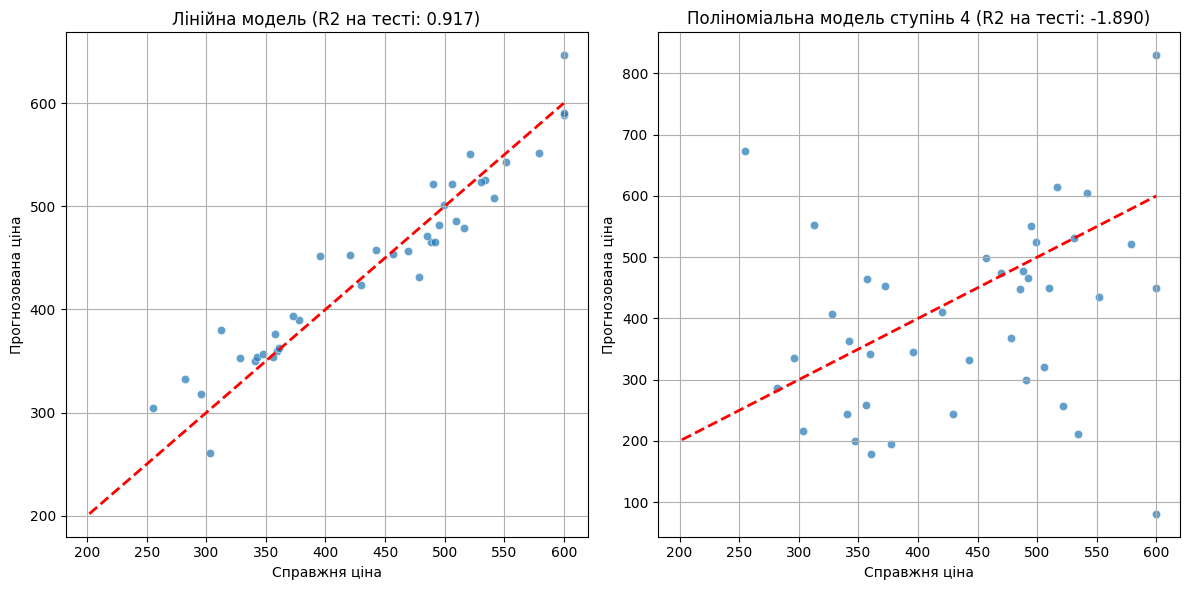

Ці графіки показують, як кожна модель вгадала ціни на курси (сині крапки) порівняно зі справжніми цінами (червона лінія).
Зверни увагу, як близько крапки знаходяться до лінії на кожному графіку.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures # Додаємо PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

np.random.seed(42)
topics = ['Програмування', 'Маркетинг', 'Дизайн', 'Мови', 'Бізнес']

data = {
    'тривалість_тижні': np.random.randint(4, 24, 200),
    'годин_відео': np.random.randint(5, 100, 200),
    'популярність_лектора': np.random.uniform(0.1, 1.0, 200), 
    'тематика': np.random.choice(topics, 200),
    'рейтинг': np.random.uniform(3.0, 5.0, 200),
    'ціна': np.random.uniform(20, 500, 200)
}
df = pd.DataFrame(data)

# Наша формула
df['ціна'] = (df['тривалість_тижні'] * 5 +
              df['годин_відео'] * 2.5 +
              df['популярність_лектора'] * 150 +
              df['рейтинг'] * 30 +
              df['тематика'].apply(lambda x: 50 if x == 'Програмування' else (30 if x == 'Маркетинг' else 0)) +
              np.random.normal(0, 30, 200) + 10 
             ).clip(10, 600) # Обмежуємо ціну

print("Наші онлайн-курси (перші 5 рядків):\n", df.head())
print("\n------------------------------------------------\n")

# Розділяємо дані на ознаки (X) та цільову змінну (y)
X = df.drop('ціна', axis=1)  # Ознаки
y = df['ціна']  # Змінна

# Розділяємо дані на навчання та тест (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Ми маємо {len(X_train)} курсів для навчання та {len(X_test)} курсів для перевірки.")
print("\n------------------------------------------------\n")

numeric_features = ['тривалість_тижні', 'годин_відео', 'популярність_лектора', 'рейтинг']
categorical_features = ['тематика']

# Створюємо препроцесор для всіх моделей (масштабування + кодування)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)


print("--- Навчаємо Лінійну модель ---") # МОДЕЛЬ 1: ЛІНІЙНА РЕГРЕСІЯ

linear_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

linear_model_pipeline.fit(X_train, y_train)

# Прогнози та оцінка на навчальних даних
y_train_pred_linear = linear_model_pipeline.predict(X_train)
r2_train_linear = r2_score(y_train, y_train_pred_linear)
mae_train_linear = mean_absolute_error(y_train, y_train_pred_linear)

# Прогнози та оцінка на тестових даних
y_test_pred_linear = linear_model_pipeline.predict(X_test)
r2_test_linear = r2_score(y_test, y_test_pred_linear)
mae_test_linear = mean_absolute_error(y_test, y_test_pred_linear)

print("Результати Лінійної моделі:")
print(f"  R2 (навчальні дані): {r2_train_linear:.3f}")
print(f"  MAE (навчальні дані): {mae_train_linear:.3f}")
print(f"  R2 (тестові дані): {r2_test_linear:.3f}")
print(f"  MAE (тестові дані): {mae_test_linear:.3f}")
print("\n------------------------------------------------\n")


print("--- Навчаємо Поліноміальну модель (ступінь 4) ---")   # МОДЕЛЬ 2: ПОЛІНОМІАЛЬНА РЕГРЕСІЯ (ступінь 4)

polynomial_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('poly_features', PolynomialFeatures(degree=4, include_bias=False)), # Додаємо поліноміальні ознаки
    ('regressor', LinearRegression()) # Використовуємо Лінійну регресію
])

polynomial_model_pipeline.fit(X_train, y_train)

# Прогнози та оцінка на навчальних даних
y_train_pred_poly = polynomial_model_pipeline.predict(X_train)
r2_train_poly = r2_score(y_train, y_train_pred_poly)
mae_train_poly = mean_absolute_error(y_train, y_train_pred_poly)

# Прогнози та оцінка на тестових даних
y_test_pred_poly = polynomial_model_pipeline.predict(X_test)
r2_test_poly = r2_score(y_test, y_test_pred_poly)
mae_test_poly = mean_absolute_error(y_test, y_test_pred_poly)

print("Результати Поліноміальної моделі (ступінь 4):")
print(f"  R2 (навчальні дані): {r2_train_poly:.3f}")
print(f"  MAE (навчальні дані): {mae_train_poly:.3f}")
print(f"  R2 (тестові дані): {r2_test_poly:.3f}")
print(f"  MAE (тестові дані): {mae_test_poly:.3f}")
print("\n------------------------------------------------\n")


print("--- Аналіз перенавчання/недонавчання ---")

# Аналіз Лінійної моделі
print("\nАналіз Лінійної моделі:")
if r2_train_linear < 0.6 and r2_test_linear < 0.6: 
    print("  Схоже на НЕДОНАВЧАННЯ: Модель занадто проста і не може вловити взаємозв'язки.")
    print(f"  R2 на навчальних ({r2_train_linear:.3f}) і тестових ({r2_test_linear:.3f}) даних низькі.")
elif r2_train_linear > 0.8 and r2_test_linear > 0.7:
     print("  Лінійна модель досить добре узагальнює, без явних ознак недонавчання/перенавчання.")
else:
    print("  Лінійна модель показує адекватні результати для своєї простоти.")

# Аналіз Поліноміальної моделі
print("\nАналіз Поліноміальної моделі (ступінь 4):")
if r2_train_poly > r2_test_poly + 0.15: # Якщо R2 на навчальних значно вищий, ніж на тестових
    print("  Схоже на ПЕРЕНАВЧАННЯ: Модель занадто складна і запам'ятала шум у навчальних даних.")
    print(f"  R2 на навчальних ({r2_train_poly:.3f}) значно вищий, ніж на тестових ({r2_test_poly:.3f}).")
    print("  Модель погано узагальнює нові дані.")
elif r2_train_poly < 0.6 and r2_test_poly < 0.6:
    print("  Схоже на НЕДОНАВЧАННЯ: Навіть поліноміальна модель занадто проста або дані складні.")
    print(f"  R2 на навчальних ({r2_train_poly:.3f}) і тестових ({r2_test_poly:.3f}) даних низькі.")
elif r2_train_poly >= r2_test_poly - 0.05 and r2_train_poly > 0.7:
    print("  Поліноміальна модель добре узагальнює і має хороші показники на обох наборах даних.")
else:
    print("  Поліноміальна модель показує помірні результати.")

print("\n------------------------------------------------\n")


# Створимо візуалізацію прогнозів для порівняння
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_test_pred_linear, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r', linewidth=2)
plt.title(f'Лінійна модель (R2 на тесті: {r2_test_linear:.3f})')
plt.xlabel('Справжня ціна')
plt.ylabel('Прогнозована ціна')
plt.grid(True)

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_test_pred_poly, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r', linewidth=2)
plt.title(f'Поліноміальна модель ступінь 4 (R2 на тесті: {r2_test_poly:.3f})')
plt.xlabel('Справжня ціна')
plt.ylabel('Прогнозована ціна')
plt.grid(True)

plt.tight_layout()
plt.show()

print("Ці графіки показують, як кожна модель вгадала ціни на курси (сині крапки) порівняно зі справжніми цінами (червона лінія).")
print("Зверни увагу, як близько крапки знаходяться до лінії на кожному графіку.")

# 9. Крос-валідація: Вартість оренди автомобіля
- Суть:
    - Датасет:
        - бренд,
        - тип кузова,
        - вік,
        - пробіг,
        - тип пального,
        - ціна оренди/день.
- Завдання:
    - Провести 10-fold крос-валідацію.
    - Оцінити середній R² та MAE.
    - Пояснити, чому крос-валідація дає більш надійну оцінку.

Наші автомобілі (перші 5 рядків):
       бренд    тип_кузова  вік  пробіг тип_пального  ціна_оренди_день
0      Ford  Позашляховик    7   85353       Дизель         39.398822
1     Honda  Позашляховик    2   75953      Електро         69.077035
2  Mercedes  Позашляховик   11   67458       Бензин         76.853392
3     Honda       Хетчбек   10   30358      Електро         34.347760
4     Honda       Хетчбек    2   13267       Бензин         39.762948

------------------------------------------------

Конвеєр для обробки даних та навчання моделі створено.

------------------------------------------------

Проводимо 10-fold крос-валідацію...

--- Результати 10-fold крос-валідації ---
R2 для кожного фолду: [0.598 0.718 0.564 0.735 0.847 0.326 0.514 0.634 0.72  0.719]
MAE для кожного фолду: [13.539 15.158 14.336 14.919  9.884 15.957 15.212 16.525 16.452 18.019]
Середній R2: 0.638 (Стандартне відхилення: 0.139)
Середній MAE: 15.000 (Стандартне відхилення: 2.081)

---------------------------

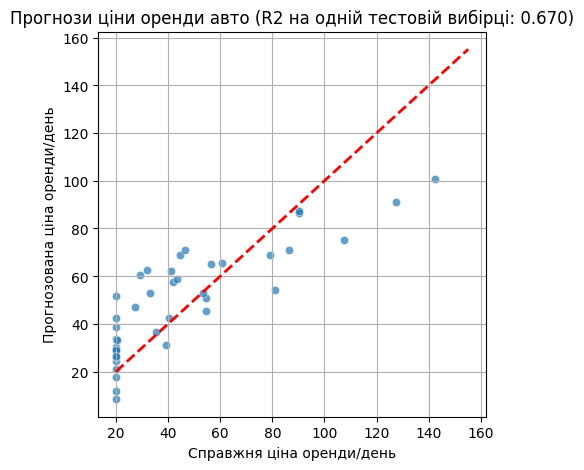

Цей графік показує, як модель вгадала ціни на автомобілі на одній тестовій вибірці.
Крос-валідація робить це багато разів і усереднює результати, даючи більш точну оцінку.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score, cross_validate # Додаємо KFold та cross_val_score/cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, make_scorer # make_scorer для крос-валідації з кількома метриками


# Датасет про автомобілі для оренди
np.random.seed(42)
brands = ['Toyota', 'BMW', 'Mercedes', 'Ford', 'Honda']
body_types = ['Седан', 'Позашляховик', 'Хетчбек', 'Універсал']
fuel_types = ['Бензин', 'Дизель', 'Електро']

data = {
    'бренд': np.random.choice(brands, 200),
    'тип_кузова': np.random.choice(body_types, 200),
    'вік': np.random.randint(1, 15, 200), # Вік автомобіля в роках
    'пробіг': np.random.randint(10000, 200000, 200),
    'тип_пального': np.random.choice(fuel_types, 200),
    'ціна_оренди_день': np.random.uniform(30, 200, 200) 
}
df = pd.DataFrame(data)

# Наша формула
df['ціна_оренди_день'] = (df['вік'] * -5 + # Старіші авто дешевші
                        df['пробіг'] * -0.0005 + # Більший пробіг дешевше
                        df['бренд'].apply(lambda x: 50 if x in ['BMW', 'Mercedes'] else (20 if x == 'Toyota' else 0)) +
                        df['тип_кузова'].apply(lambda x: 30 if x == 'Позашляховик' else (10 if x == 'Седан' else 0)) +
                        df['тип_пального'].apply(lambda x: 40 if x == 'Електро' else (10 if x == 'Дизель' else 0)) +
                        np.random.normal(0, 15, 200) + 70 # Базова ціна та шум
                       ).clip(20, 250) # Наша ціна

print("Наші автомобілі (перші 5 рядків):\n", df.head())
print("\n------------------------------------------------\n")

# Розділимо дані на ознаки (X) та цільову змінну (y)
X = df.drop('ціна_оренди_день', axis=1)
y = df['ціна_оренди_день']

# Визначимо числові та категоріальні колонки
numeric_features = ['вік', 'пробіг']
categorical_features = ['бренд', 'тип_кузова', 'тип_пального']

# Створимо препроцесор для масштабування та кодування
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

# Створимо повний конвеєр (Pipeline)
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression()) 
])

print("Конвеєр для обробки даних та навчання моделі створено.")
print("\n------------------------------------------------\n")


print("Проводимо 10-fold крос-валідацію...")
# Ствоимо об'єкт KFold для 10 розбиття
cv = KFold(n_splits=10, shuffle=True, random_state=42)

# Визначаємо метрики, які ми хочемо оцінити
scoring = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error' 
}

# Виконуємо крос-валідацію
cv_results = cross_validate(model_pipeline, X, y, cv=cv, scoring=scoring, return_train_score=False)
mae_scores = -cv_results['test_mae']
r2_scores = cv_results['test_r2']

print("\n--- Результати 10-fold крос-валідації ---")
print(f"R2 для кожного фолду: {r2_scores.round(3)}")
print(f"MAE для кожного фолду: {mae_scores.round(3)}")
print(f"Середній R2: {np.mean(r2_scores):.3f} (Стандартне відхилення: {np.std(r2_scores):.3f})")
print(f"Середній MAE: {np.mean(mae_scores):.3f} (Стандартне відхилення: {np.std(mae_scores):.3f})")

print("\n------------------------------------------------\n")

# Заключення чому крос-валідація дає більш надійну оцінку
print("--- Чому крос-валідація дає більш надійну оцінку? ---")
print("Якщо у нас є 10 різних 'тестів' для нашої моделі.")
print("Замість того, щоб покладатися лише на один результат (якщо б ми ділили дані лише один раз на train/test),")
print("ми проводимо навчання та перевірку 10 разів, щоразу використовуючи різні частини даних.")
print("\nЦе надійніше, тому що:")
print("1.  Кожен шматочок даних побуває в тестовій частині рівно один раз. Це означає, що ми отримуємо об'єктивну оцінку на всіх наших даних.")
print("2.  Модель навчається на різних підмножинах даних. Це допомагає перевірити, чи не 'перевчилася' модель на якийсь конкретний набір даних, і чи може вона добре працювати на 'нових' даних.")
print("3.  Зменшується вплив випадковості. Якщо якийсь один 'тест' був легким або складним, його вплив 'розмивається' серед інших 9 тестів, і ми отримуємо більш стабільну та усереднену оцінку продуктивності моделі.")
print("Таким чином, середній R2 та MAE, отримані за допомогою крос-валідації, дають нам набагато краще уявлення про те, як наша модель буде працювати в реальних умовах, на даних, які вона ще ніколи не бачила.")

print("\n------------------------------------------------\n")

# Покажемо на графіку (для одного з фолдів, наприклад, останнього)
# Знову навчимо модель на всіх даних і зробимо прогноз
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(X, y, test_size=0.2, random_state=42)
model_pipeline.fit(X_train_final, y_train_final)
y_pred_final = model_pipeline.predict(X_test_final)
r2_final = r2_score(y_test_final, y_pred_final)

plt.figure(figsize=(5, 5))
sns.scatterplot(x=y_test_final, y=y_pred_final, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r', linewidth=2)
plt.title(f'Прогнози ціни оренди авто (R2 на одній тестовій вибірці: {r2_final:.3f})')
plt.xlabel('Справжня ціна оренди/день')
plt.ylabel('Прогнозована ціна оренди/день')
plt.grid(True)
plt.show()

print("Цей графік показує, як модель вгадала ціни на автомобілі на одній тестовій вибірці.")
print("Крос-валідація робить це багато разів і усереднює результати, даючи більш точну оцінку.")

# 10. Гіперпараметри + регуляризація: Прогноз вартості доставки
- Суть:
    - Дані доставки:
        - відстань,
        - вага /є корельовані змінні (вага й об’єм)/,
        - терміновість,
        - тип упаковки,
        - перевізник. 
- Завдання:
    - Побудувати моделі Lasso та Ridge з різними значеннями alpha.
    - Порівняти коефіцієнти.
    - Визначити, які ознаки Lasso зануляє, і як Ridge "згладжує".

Порівняння коефіцієнтів Lasso та Ridge для різних alpha:
----------------------------------------------------------------------

Alpha = 0.001:
  Lasso Coefficients:
    відстань: 12.2962
    вага: 4.2560
    об'єм: 14.3383
    терміновість: 8.3694
    тип упаковки: 3.6417
    перевізник: 3.8902
  Ridge Coefficients:
    відстань: 12.2986
    вага: 4.1905
    об'єм: 14.4046
    терміновість: 8.3693
    тип упаковки: 3.6416
    перевізник: 3.8923
----------------------------------------------------------------------

Alpha = 0.01:
  Lasso Coefficients:
    відстань: 12.2864
    вага: 4.2850
    об'єм: 14.2978
    терміновість: 8.3591
    тип упаковки: 3.6358
    перевізник: 3.8806
  Ridge Coefficients:
    відстань: 12.2951
    вага: 4.2716
    об'єм: 14.3219
    терміновість: 8.3696
    тип упаковки: 3.6424
    перевізник: 3.8903
----------------------------------------------------------------------

Alpha = 0.1:
  Lasso Coefficients:
    відстань: 12.1945
    вага: 4.3386
    об'єм: 1

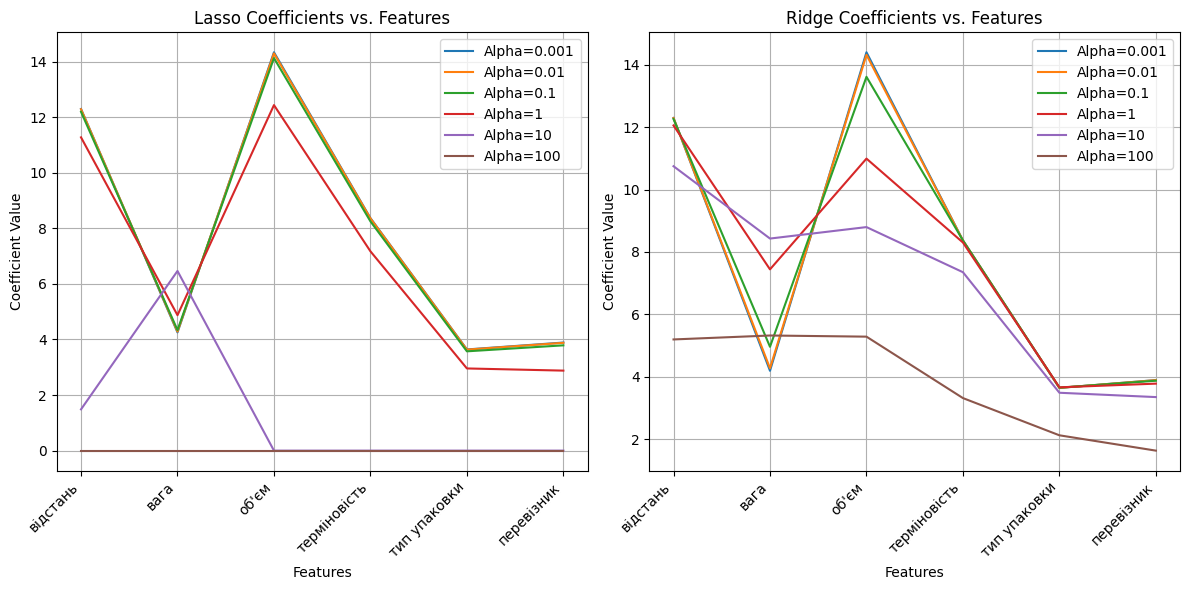

----------------------------------------------------------------------

Аналіз занулення ознак Lasso:
  Для Alpha=0.001, Lasso не занулив жодних ознак.
  Для Alpha=0.01, Lasso не занулив жодних ознак.
  Для Alpha=0.1, Lasso не занулив жодних ознак.
  Для Alpha=1, Lasso не занулив жодних ознак.
  Для Alpha=10, Lasso занулив ознаки: об'єм, терміновість, тип упаковки, перевізник
  Для Alpha=100, Lasso занулив ознаки: відстань, вага, об'єм, терміновість, тип упаковки, перевізник

Аналіз згладжування коефіцієнтів Ridge:
  Для великого Alpha=100:
    Lasso коефіцієнти:
      відстань: 0.0000
      вага: 0.0000
      об'єм: 0.0000
      терміновість: 0.0000
      тип упаковки: 0.0000
      перевізник: 0.0000
    Ridge коефіцієнти:
      відстань: 5.1955
      вага: 5.3218
      об'єм: 5.2851
      терміновість: 3.3152
      тип упаковки: 2.1216
      перевізник: 1.6301


In [6]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n_samples = 100

distance = np.random.rand(n_samples) * 100 # км
weight = np.random.rand(n_samples) * 50    # кг
volume = weight * 0.8 + np.random.rand(n_samples) * 5  # об'єм залежить від ваги
urgency = np.random.randint(0, 3, n_samples) # 0-низька, 1-середня, 2-висока
packaging_type = np.random.randint(0, 2, n_samples) # 0-мала, 1-велика
carrier = np.random.randint(0, 3, n_samples) # 0, 1, 2

# Наша формула
delivery_cost = (distance * 0.5 + weight * 1.2 + volume * 0.3 +
                 urgency * 10 + packaging_type * 5 + carrier * 7 +
                 np.random.randn(n_samples) * 15)

df = pd.DataFrame({
    'відстань': distance,
    'вага': weight,
    'об\'єм': volume,
    'терміновість': urgency,
    'тип упаковки': packaging_type,
    'перевізник': carrier,
    'вартість доставки': delivery_cost
})

X = df[['відстань', 'вага', 'об\'єм', 'терміновість', 'тип упаковки', 'перевізник']]  # ознаки
y = df['вартість доставки']  # ціль

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Ділимо на тренувальні (для навчання) та тестові (для перевірки)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Створюємо список значень alpha для експериментів
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

print("Порівняння коефіцієнтів Lasso та Ridge для різних alpha:")
print("-" * 70)

lasso_coefficients = {} # Тут будемо зберігати коефіцієнти Lasso для кожної alpha
ridge_coefficients = {} # Тут будемо зберігати коефіцієнти Ridge для кожної alpha

for alpha in alphas:
    # Модель Lasso
    lasso = Lasso(alpha=alpha, random_state=42, max_iter=2000) 
    lasso.fit(X_train, y_train)
    lasso_coefficients[alpha] = lasso.coef_ 

    # Модель Ridge
    ridge = Ridge(alpha=alpha, random_state=42)
    ridge.fit(X_train, y_train)
    ridge_coefficients[alpha] = ridge.coef_ 

    print(f"\nAlpha = {alpha}:")
    print("  Lasso Coefficients:")
    for feature, coef in zip(X.columns, lasso_coefficients[alpha]): 
        print(f"    {feature}: {coef:.4f}")

    print("  Ridge Coefficients:")
    for feature, coef in zip(X.columns, ridge_coefficients[alpha]): 
        print(f"    {feature}: {coef:.4f}")
    print("-" * 70)

# Зобразимо все
features = X.columns
plt.figure(figsize=(12, 6))

# Lasso коефіцієнти
plt.subplot(1, 2, 1)
for i, alpha in enumerate(alphas):
    plt.plot(features, lasso_coefficients[alpha], label=f'Alpha={alpha}')
plt.title('Lasso Coefficients vs. Features')
plt.xlabel('Features')
plt.ylabel('Coefficient Value') 
plt.legend()
plt.grid(True)
plt.xticks(rotation=45, ha='right')

# Ridge коефіцієнти
plt.subplot(1, 2, 2)
for i, alpha in enumerate(alphas):
    plt.plot(features, ridge_coefficients[alpha], label=f'Alpha={alpha}')
plt.title('Ridge Coefficients vs. Features')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()
print("-" * 70)

print("\nАналіз занулення ознак Lasso:")
for alpha in alphas:
    zeroed_features_lasso = [feature for feature, coef in zip(X.columns, lasso_coefficients[alpha]) if abs(coef) < 1e-4]
    if zeroed_features_lasso:
        print(f"  Для Alpha={alpha}, Lasso занулив ознаки: {', '.join(zeroed_features_lasso)}")
    else:
        print(f"  Для Alpha={alpha}, Lasso не занулив жодних ознак.")

print("\nАналіз згладжування коефіцієнтів Ridge:")
alpha_large = max(alphas)
print(f"  Для великого Alpha={alpha_large}:")
print("    Lasso коефіцієнти:")
for feature, coef in zip(X.columns, lasso_coefficients[alpha_large]):
    print(f"      {feature}: {coef:.4f}")
print("    Ridge коефіцієнти:")
for feature, coef in zip(X.columns, ridge_coefficients[alpha_large]):
    print(f"      {feature}: {coef:.4f}")